# Starlink Characterization - WD

---

Crie uma um diretório 'data' na raíz. Coloque a pasta métricas Prometheus dentro desse diretório com o nome 'metricas_prometheus'.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib
import pandas as pd
import seaborn as sns
import numpy

In [2]:
ROOT = Path(os.getcwd()).parent

sys.path.append(str(ROOT))

DIR_DATA = ROOT / 'data'
DIR_OUT  = ROOT / 'output'
DIR_SRC  = ROOT / 'src'
DIR_PROM = DIR_DATA / 'metricas_prometheus'

DIR_DATA.mkdir(exist_ok=True)

STARLINK_PATH    = DIR_DATA / 'starlink_wd.xlsx'
NETFLOW_PATH     = DIR_DATA / 'netflow_all.csv'
FLUXOS_PATH      = DIR_DATA / 'fluxos.json'
FLUXOS_CONF_PATH = DIR_DATA / 'fluxos_conf.parquet'

In [3]:
if not STARLINK_PATH.exists():
    print('Arquivo não encontrado!')
else:
    df_sl = pd.read_excel(STARLINK_PATH)
    print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [4]:
if not FLUXOS_CONF_PATH.exists():
    print('Arquivo não encontrado!')
else:
    df_fc = pd.read_parquet(FLUXOS_CONF_PATH)
    print('Dados carregados com sucesso!')

Dados carregados com sucesso!


## 1. Tratamento de Dados

In [5]:
from src.data_utils import (
    format_netflow_ts,
    format_starlink_ts,
    netflow_agg,
    starlink_agg,
    split_by_gap,
    sync_time_boundaries
)

In [6]:
# Formatação de timestamps
df_sl = format_starlink_ts(df_sl)
df_fc = format_netflow_ts(df_fc)

In [7]:
# Sincronização da janela de tempo
df_sl, df_fc = sync_time_boundaries(df_sl, df_fc)

In [8]:
# Divisão dos dados em antes
# e depois de gap de 9h
(split_data_a, split_data_b) = split_by_gap(
    df_sl,
    df_fc,
)

df_sl_pre, df_fc_pre = split_data_a
df_sl_post, df_fc_post = split_data_b

In [9]:
FREQ = '10min'

# Agregação dos datasets
df_sl_pre_agg = starlink_agg(df_sl_pre, FREQ)
df_fc_pre_agg = netflow_agg(df_fc_pre, FREQ)

df_sl_post_agg = starlink_agg(df_sl_post, FREQ)
df_fc_post_agg = netflow_agg(df_fc_post, FREQ)

## 2. Plotagem

In [11]:
from src.plot_utils import (
    plot_correlation_series,
    plot_physical_states_boxplot,
    plot_correlation_scatter,
    plot_flow_duration_histogram
)

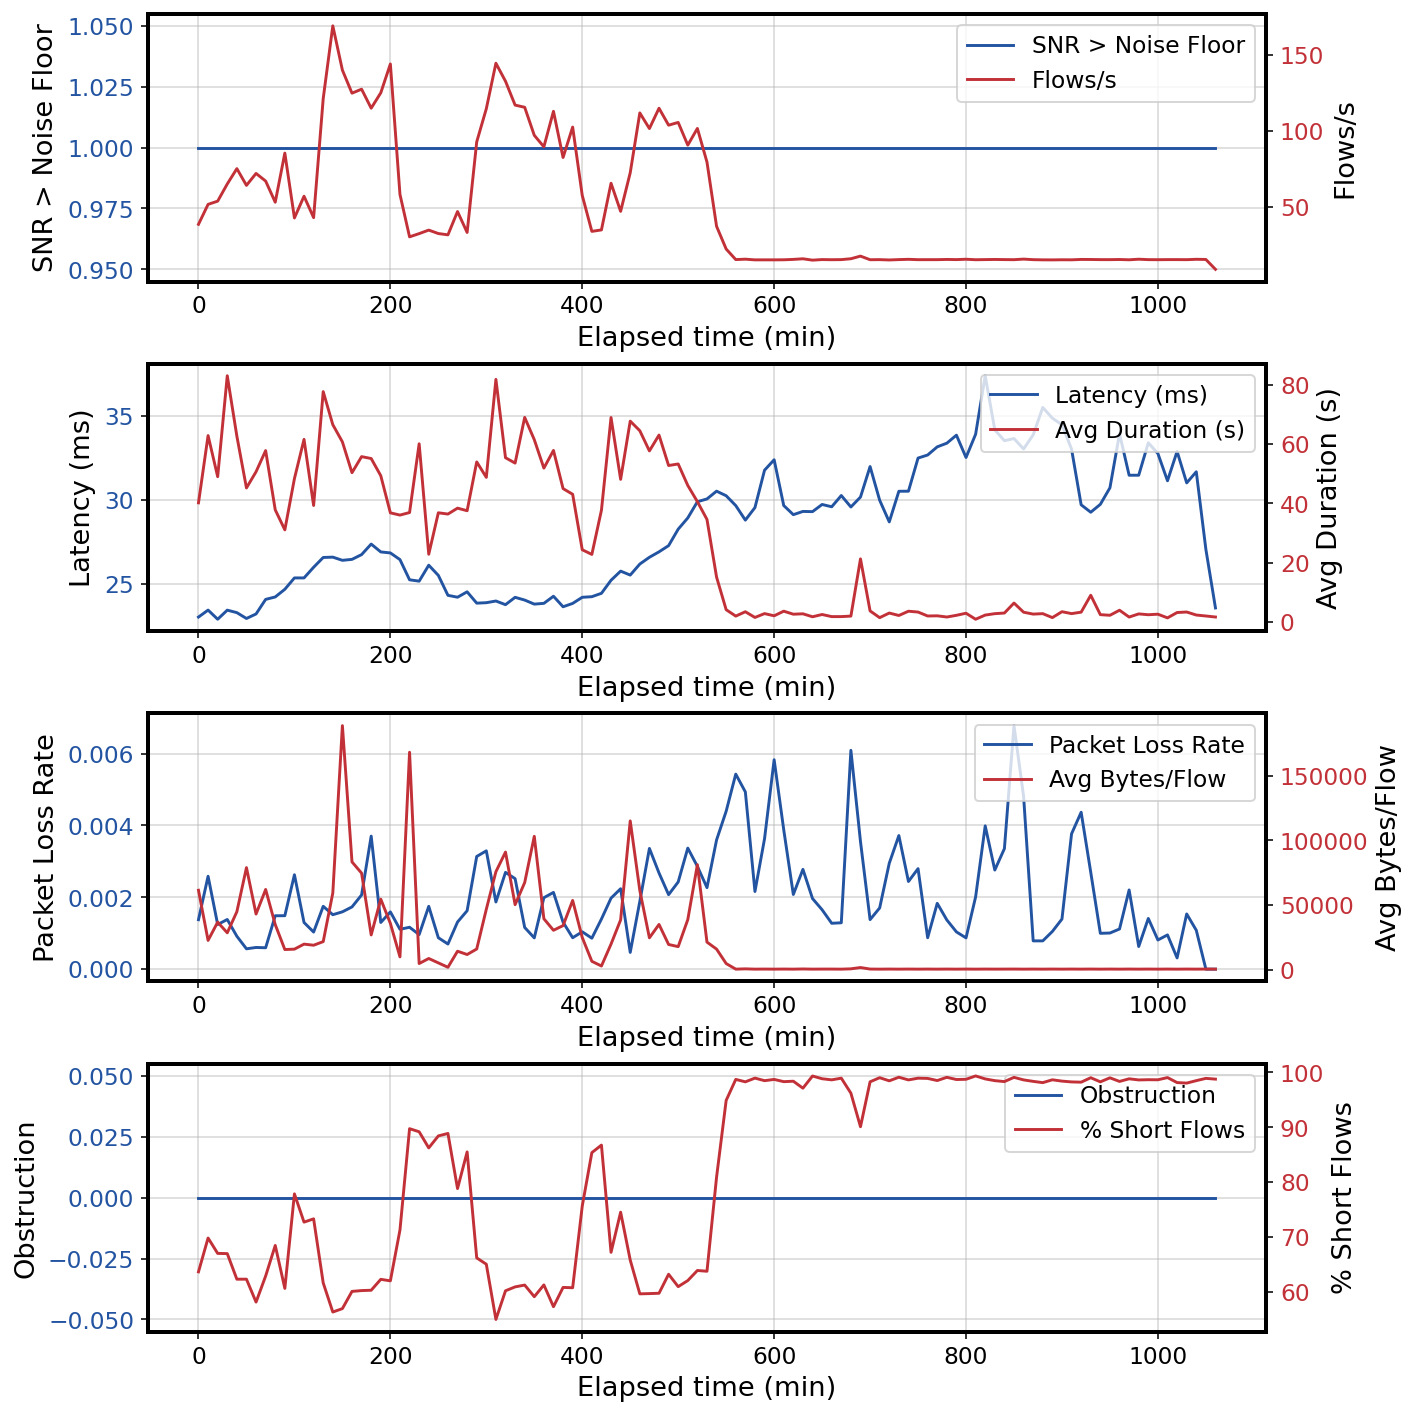

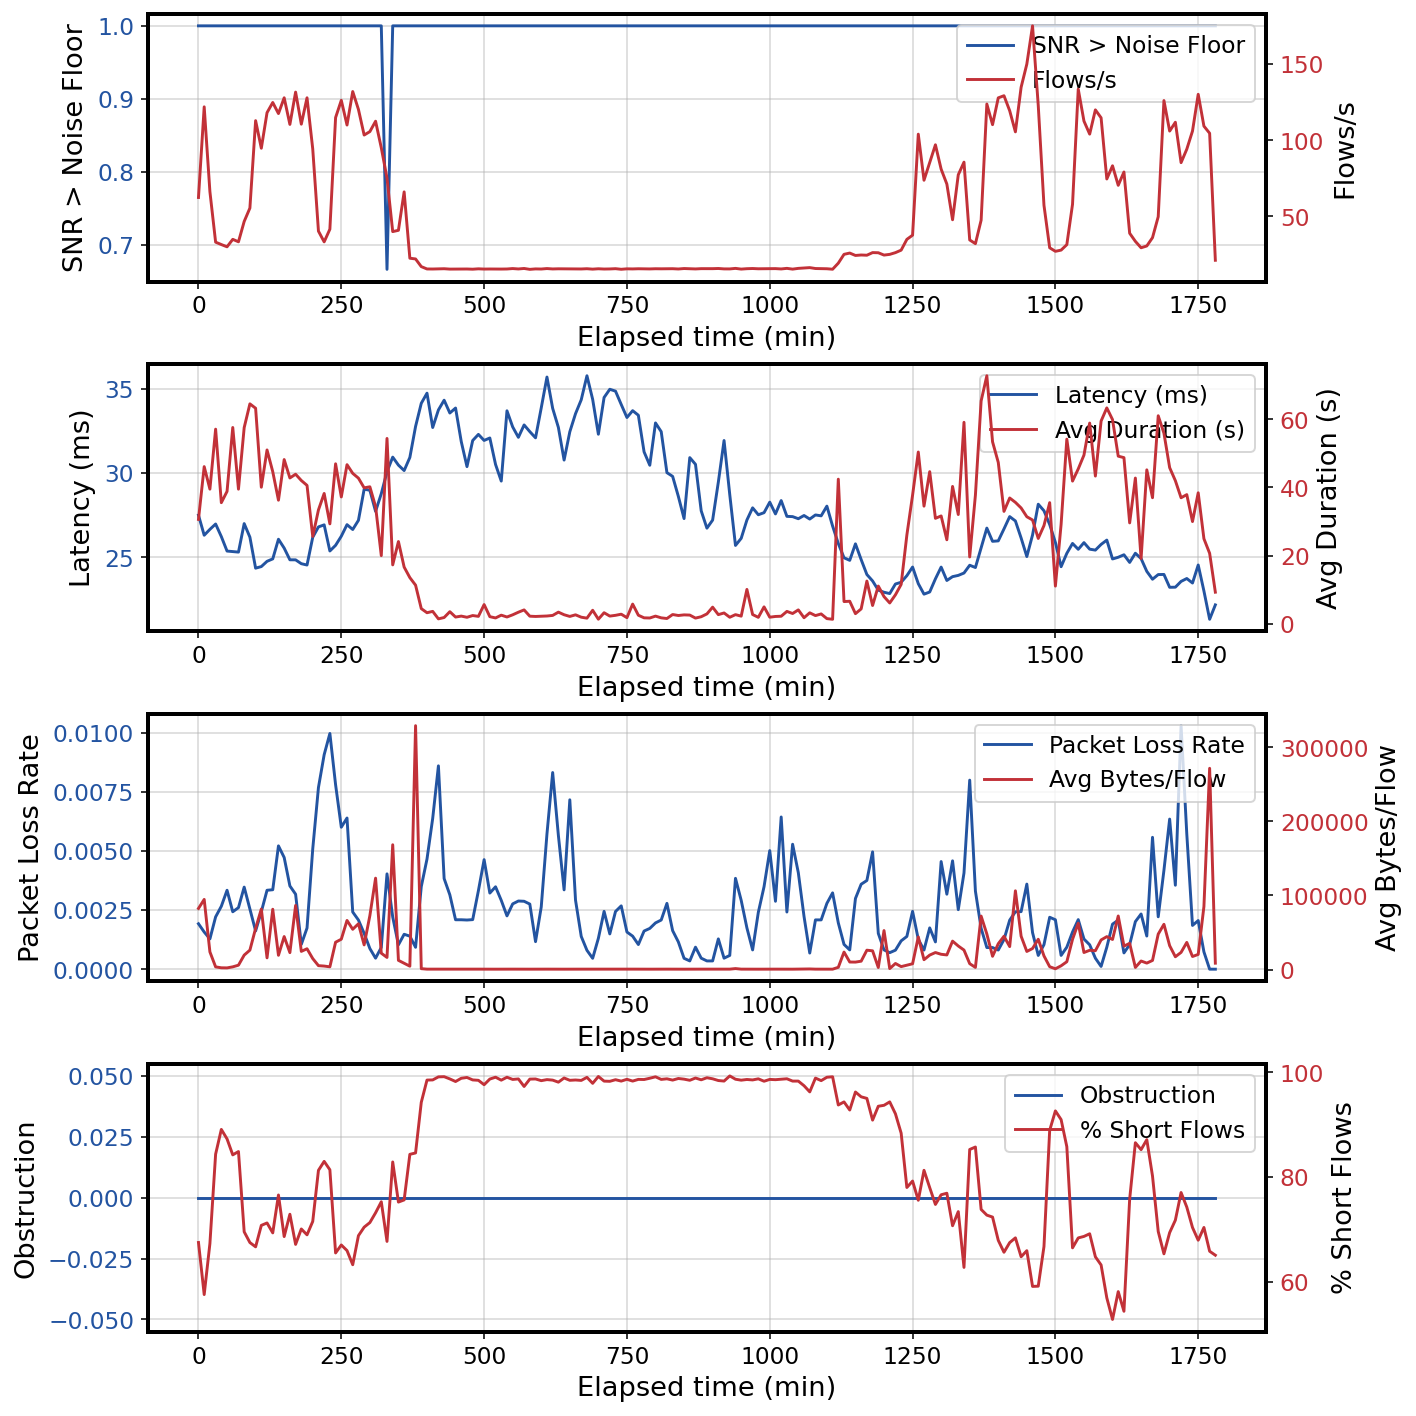

In [17]:
for df in [df_sl_pre_agg, df_fc_pre_agg, df_sl_post_agg, df_fc_post_agg]:
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

plot_correlation_series(df_sl_pre_agg, df_fc_pre_agg, DIR_OUT / 'time_series_pre_gap')
plot_correlation_series(df_sl_post_agg, df_fc_post_agg, DIR_OUT / 'time_series_post_gap')

In [13]:
df_sl_agg = pd.concat([df_sl_pre_agg, df_sl_post_agg])
df_fc_agg = pd.concat([df_fc_pre_agg, df_fc_post_agg])

In [14]:
plot_physical_states_boxplot(df_sl_agg, df_fc_agg, DIR_OUT)

/net/truenas.labgen.lid.uff.br/mnt/labgen/raraujo/starlink-wd/src/plot_utils.py:181: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/net/truenas.labgen.lid.uff.br/mnt/labgen/raraujo/starlink-wd/src/plot_utils.py:181: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/net/truenas.labgen.lid.uff.br/mnt/labgen/raraujo/starlink-wd/src/plot_utils.py:181: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


In [15]:
plot_correlation_scatter(df_sl_agg, df_fc_agg, DIR_OUT)

In [16]:
plot_flow_duration_histogram(df_sl_agg, df_fc_agg, DIR_OUT)